In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [2]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/spectra/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-08-31 12:00:00',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-10-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10) # add + offset to continue
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-12-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30+1 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

In [5]:
import numba
import xgcm 
grid = xgcm.Grid(ds_tpose_TAO, periodic=False)
UVEL = grid.interp(ds_tpose_TAO.UVEL, 'X', boundary='fill')
grid = xgcm.Grid(ds_tpose_noTAO, periodic=False)
UVEL_noTAO = grid.interp(ds_tpose_noTAO.UVEL, 'X', boundary='fill')

In [6]:
grid = xgcm.Grid(ds_tpose_TAO, periodic=False)
VVEL = grid.interp(ds_tpose_TAO.VVEL, 'Y', boundary='fill')
grid = xgcm.Grid(ds_tpose_noTAO, periodic=False)
VVEL_noTAO = grid.interp(ds_tpose_noTAO.VVEL, 'Y', boundary='fill')

In [7]:
import matplotlib.pyplot as plt

def plot_depth_variance(variables, labels, YC=0, lons=None, depth_slice=slice(0, -300), colors=None, linestyles=None, figsize=None):
    """
    Plot depth profiles of temporal variance for a list of xarray DataArrays.
    One subplot column per longitude.

    Parameters:
    -----------
    variables  : list of xarray DataArrays, e.g. [ds1.VVEL, ds2.UVEL]
    labels     : list of strings for the legend, same length as variables
    YC         : latitude to select (default 0)
    lons       : list of longitudes, e.g. [-140, -120, -100]. If None, no XC selection.
    depth_slice: slice for depth selection, e.g. slice(0, -300)
    figsize    : figure size tuple (auto-scaled by n_lons if None)
    """
    assert len(variables) == len(labels), "variables and labels must be the same length"

    if lons is None:
        lons = [None]

    n_lons = len(lons)
    if figsize is None:
        figsize = (4 * n_lons, 6)

    fig, axes = plt.subplots(1, n_lons, figsize=figsize, sharey=True)
    if n_lons == 1:
        axes = [axes]

    for ax, XC in zip(axes, lons):
        for da, label, color, linestyle in zip(variables, labels, colors, linestyles):
            sel_kwargs = {'method': 'nearest'}
            if 'YC' in da.dims or 'YC' in da.coords:
                da = da.sel(YC=YC, **sel_kwargs)
            if XC is not None and ('XC' in da.dims or 'XC' in da.coords):
                da = da.sel(XC=XC, **sel_kwargs)

            da = da.sel(Z=depth_slice)
            variance = da.var(dim='time').compute()

            ax.plot(variance.values, variance.Z.values, label=label, linewidth=1.8, color=color, ls=linestyle)

        title = f'{abs(XC-360)}°W' if XC is not None else 'Temporal Variance'
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Variance (m² s⁻²)', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0,0.3)

    axes[0].set_ylabel('Depth (m)', fontsize=11)
    axes[-1].legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    return fig, axes

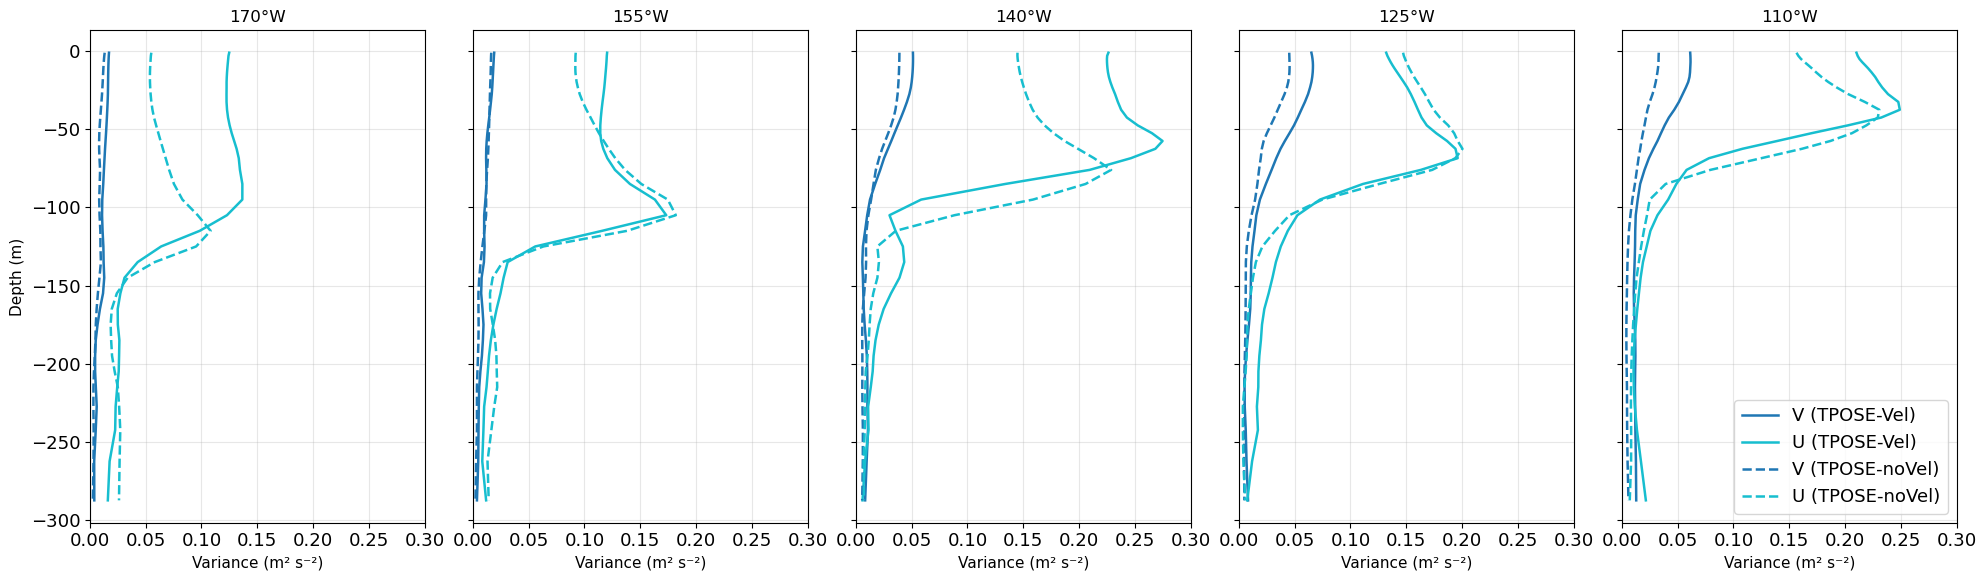

In [44]:
fig, ax = plot_depth_variance(
    variables=[VVEL, UVEL, VVEL_noTAO, UVEL_noTAO],
    labels=['V (TPOSE-Vel)', 'U (TPOSE-Vel)', 'V (TPOSE-noVel)', 'U (TPOSE-noVel)'],
    YC=0,
    lons=[190, 205, 220, 235, 250],
    depth_slice=slice(0, -300),
    colors = ['tab:blue', 'tab:cyan', 'tab:blue', 'tab:cyan'],
    linestyles=['-', '-', '--', '--'],
)
fig.savefig(foldername + 'depth_variance_profiles.png', dpi=300, bbox_inches='tight')

In [8]:
import matplotlib.pyplot as plt

def plot_depth_variance(variables, labels, YC=0, lons=None, depth_slice=slice(0, -300), colors=None, linestyles=None, figsize=None, var_pairs=None):
    """
    Plot depth profiles of temporal variance for a list of xarray DataArrays.
    One subplot column per longitude.

    Parameters:
    -----------
    variables  : list of xarray DataArrays, e.g. [ds1.VVEL, ds2.UVEL]
    labels     : list of strings for the legend, same length as variables
    YC         : latitude to select (default 0)
    lons       : list of longitudes, e.g. [-140, -120, -100]. If None, no XC selection.
    depth_slice: slice for depth selection, e.g. slice(0, -300)
    colors     : list of colors, same length as variables
    linestyles : list of linestyles, same length as variables
    figsize    : figure size tuple (auto-scaled by n_lons if None)
    var_pairs  : list of (idx_tao, idx_notao, label) tuples defining which variables to compare
                 for % increase, e.g. [(0, 2, 'V'), (1, 3, 'U')]
                 idx_tao and idx_notao are indices into the variables list
    """
    assert len(variables) == len(labels), "variables and labels must be the same length"

    if lons is None:
        lons = [None]

    n_lons = len(lons)
    if figsize is None:
        figsize = (4 * n_lons, 6)

    fig, axes = plt.subplots(1, n_lons, figsize=figsize, sharey=True)
    if n_lons == 1:
        axes = [axes]

    for ax, XC in zip(axes, lons):
        # compute integrated variance for each variable at this longitude
        integrated_vars = []
        for da in variables:
            sel_kwargs = {'method': 'nearest'}
            da_sel = da
            if 'YC' in da_sel.dims or 'YC' in da_sel.coords:
                da_sel = da_sel.sel(YC=YC, **sel_kwargs)
            if XC is not None and ('XC' in da_sel.dims or 'XC' in da_sel.coords):
                da_sel = da_sel.sel(XC=XC, **sel_kwargs)
            da_sel = da_sel.sel(Z=depth_slice)
            integrated_vars.append(da_sel.var(dim='time').integrate(coord='Z').compute())

        # plot depth profiles
        for da, label, color, linestyle in zip(variables, labels, colors, linestyles):
            sel_kwargs = {'method': 'nearest'}
            if 'YC' in da.dims or 'YC' in da.coords:
                da = da.sel(YC=YC, **sel_kwargs)
            if XC is not None and ('XC' in da.dims or 'XC' in da.coords):
                da = da.sel(XC=XC, **sel_kwargs)
            da = da.sel(Z=depth_slice)
            variance = da.var(dim='time').compute()
            ax.plot(variance.values, variance.Z.values, label=label, linewidth=1.8, color=color, ls=linestyle)

        # add % increase text boxes
        if var_pairs is not None:
            text_lines = []
            for idx_tao, idx_notao, pair_label in var_pairs:
                pct = 100 * (integrated_vars[idx_tao] - integrated_vars[idx_notao]) / integrated_vars[idx_notao]
                text_lines.append(f'Δ{pair_label}: {float(pct):.1f}%')
            text = '\n'.join(text_lines)
            ax.text(0.97, 0.03, text, transform=ax.transAxes,
                    fontsize=12, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='gray'))

        title = f'{abs(XC-360)}°W' if XC is not None else 'Temporal Variance'
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Variance (m² s⁻²)', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 0.3)

    axes[0].set_ylabel('Depth (m)', fontsize=11)
    axes[-1].legend(loc='lower left')
    plt.tight_layout()
    plt.show()
    return fig, axes

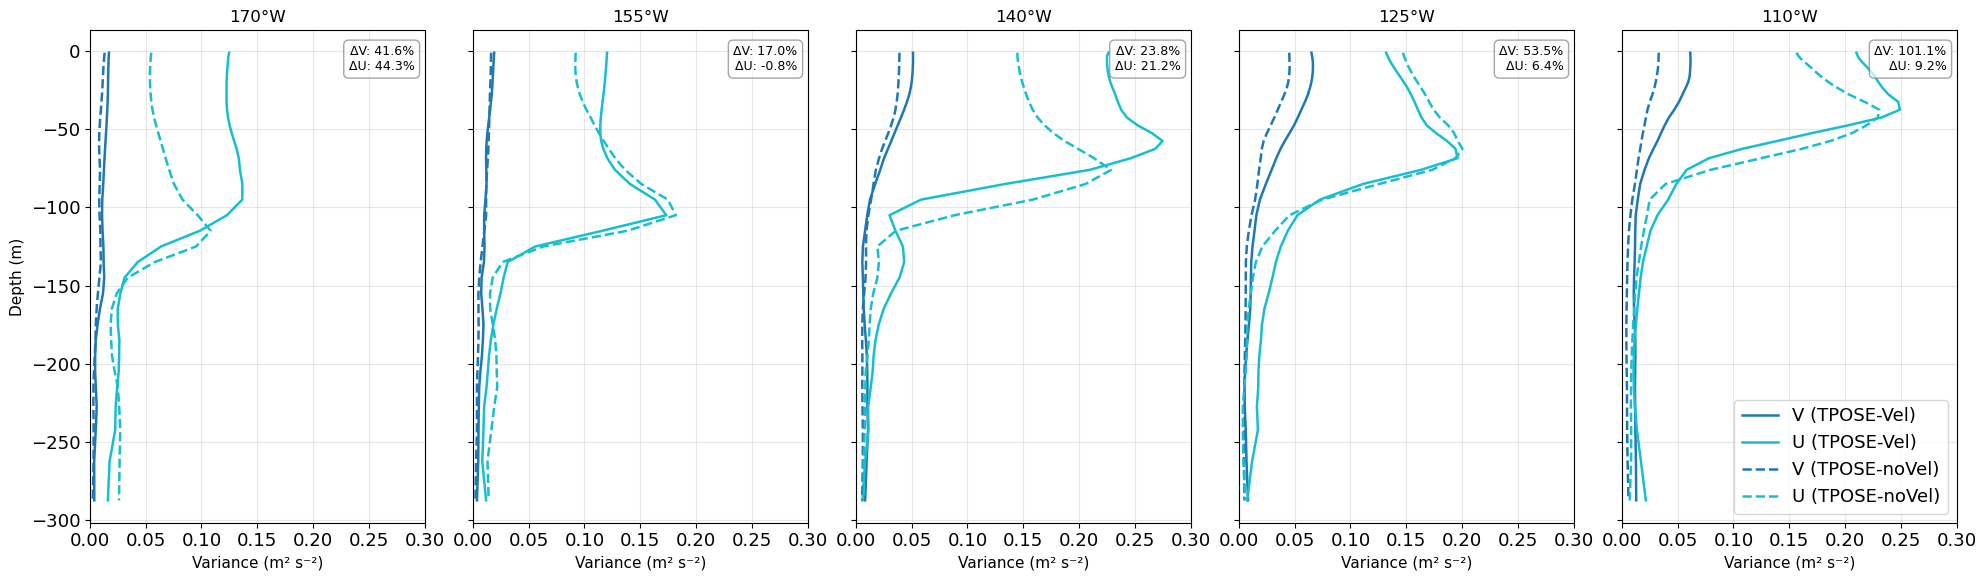

In [9]:
fig, ax = plot_depth_variance(
    variables=[VVEL, UVEL, VVEL_noTAO, UVEL_noTAO],
    labels=['V (TPOSE-Vel)', 'U (TPOSE-Vel)', 'V (TPOSE-noVel)', 'U (TPOSE-noVel)'],
    YC=0,
    lons=[190, 205, 220, 235, 250],
    depth_slice=slice(0, -300),
    colors=['tab:blue', 'tab:cyan', 'tab:blue', 'tab:cyan'],
    linestyles=['-', '-', '--', '--'],
    var_pairs=[(0, 2, 'V'), (1, 3, 'U')],  # (tao_idx, notao_idx, label)
)
fig.savefig(foldername + 'depth_variance_profiles_text.png', dpi=300, bbox_inches='tight')

In [16]:
import matplotlib.pyplot as plt

def plot_depth_variance(variables, labels, YC=0, lons=None, depth_slice=slice(0, -300), 
                        colors=None, linestyles=None, figsize=None, var_pairs=None,
                        variables_ax2=None, labels_ax2=None, colors_ax2=None, 
                        linestyles_ax2=None, var_pairs_ax2=None, xlabel_ax2='Variance (°C²)'):
    """
    Plot depth profiles of temporal variance for a list of xarray DataArrays.
    One subplot column per longitude. Optionally a second x-axis (top) for a second
    set of variables (e.g. temperature) with different units.

    Parameters:
    -----------
    variables      : list of xarray DataArrays for primary x-axis (bottom)
    labels         : list of strings for the legend, same length as variables
    YC             : latitude to select (default 0)
    lons           : list of longitudes. If None, no XC selection.
    depth_slice    : slice for depth selection, e.g. slice(0, -300)
    colors         : list of colors, same length as variables
    linestyles     : list of linestyles, same length as variables
    figsize        : figure size tuple (auto-scaled by n_lons if None)
    var_pairs      : list of (idx_tao, idx_notao, label) for primary axis % increase
    variables_ax2  : list of xarray DataArrays for secondary x-axis (top)
    labels_ax2     : list of strings for the legend, same length as variables_ax2
    colors_ax2     : list of colors, same length as variables_ax2
    linestyles_ax2 : list of linestyles, same length as variables_ax2
    var_pairs_ax2  : list of (idx_tao, idx_notao, label) for secondary axis % increase
    xlabel_ax2     : x-axis label for secondary axis
    """
    assert len(variables) == len(labels), "variables and labels must be the same length"
    if variables_ax2 is not None:
        assert len(variables_ax2) == len(labels_ax2), "variables_ax2 and labels_ax2 must be the same length"

    if lons is None:
        lons = [None]

    n_lons = len(lons)
    if figsize is None:
        figsize = (4 * n_lons, 6)

    fig, axes = plt.subplots(1, n_lons, figsize=figsize, sharey=True)
    if n_lons == 1:
        axes = [axes]

    for ax, XC in zip(axes, lons):

        def sel_da(da):
            sel_kwargs = {'method': 'nearest'}
            if 'YC' in da.dims or 'YC' in da.coords:
                da = da.sel(YC=YC, **sel_kwargs)
            if XC is not None and ('XC' in da.dims or 'XC' in da.coords):
                da = da.sel(XC=XC, **sel_kwargs)
            return da.sel(Z=depth_slice)

        # compute integrated variance for primary variables
        integrated_vars = [sel_da(da).var(dim='time').integrate(coord='Z').compute() for da in variables]

        # plot primary depth profiles
        for da, label, color, linestyle in zip(variables, labels, colors, linestyles):
            variance = sel_da(da).var(dim='time').compute()
            ax.plot(variance.values, variance.Z.values, label=label, linewidth=1.8, color=color, ls=linestyle)

        ax.set_xlabel('Variance (m² s⁻²)', fontsize=11)
        ax.set_xlim(0, 0.3)

        # secondary axis (top) for temperature or other variables
        if variables_ax2 is not None:
            ax2 = ax.twiny()

            # compute integrated variance for secondary variables
            integrated_vars_ax2 = [sel_da(da).var(dim='time').integrate(coord='Z').compute() for da in variables_ax2]

            for da, label, color, linestyle in zip(variables_ax2, labels_ax2, colors_ax2, linestyles_ax2):
                variance = sel_da(da).var(dim='time').compute()
                ax2.plot(variance.values, variance.Z.values, label=label, linewidth=1.8, color=color, ls=linestyle)

            ax2.set_xlabel(xlabel_ax2, fontsize=11)
            ax2.set_xlim(0, 4.1)
            
            # build text box combining both var_pairs
            text_lines = []
            if var_pairs is not None:
                for idx_tao, idx_notao, pair_label in var_pairs:
                    pct = 100 * (integrated_vars[idx_tao] - integrated_vars[idx_notao]) / integrated_vars[idx_notao]
                    text_lines.append(f'Δ{pair_label}: {float(pct):.1f}%')
            if var_pairs_ax2 is not None:
                for idx_tao, idx_notao, pair_label in var_pairs_ax2:
                    pct = 100 * (integrated_vars_ax2[idx_tao] - integrated_vars_ax2[idx_notao]) / integrated_vars_ax2[idx_notao]
                    text_lines.append(f'Δ{pair_label}: {float(pct):.1f}%')

            # legend: combine both axes into one
            handles1, labels1 = ax.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            if ax == axes[-1]:
                ax2.legend(handles1 + handles2, labels1 + labels2, loc='lower left', fontsize=12)

        else:
            # no secondary axis — text box from primary var_pairs only
            text_lines = []
            if var_pairs is not None:
                for idx_tao, idx_notao, pair_label in var_pairs:
                    pct = 100 * (integrated_vars[idx_tao] - integrated_vars[idx_notao]) / integrated_vars[idx_notao]
                    text_lines.append(f'Δ{pair_label}: {float(pct):.1f}%')

        if text_lines:
            ax.text(0.97, 0.03, '\n'.join(text_lines), transform=ax.transAxes,
                    fontsize=12, verticalalignment='bottom', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='gray'))

        title = f'{abs(XC-360)}°W' if XC is not None else 'Temporal Variance'
        ax.set_title(title, fontsize=14)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('Depth (m)', fontsize=11)
    if variables_ax2 is None:
        axes[-1].legend(loc='lower left', fontsize=12, framealpha=1.0)

    plt.tight_layout()
    plt.show()
    return fig, axes

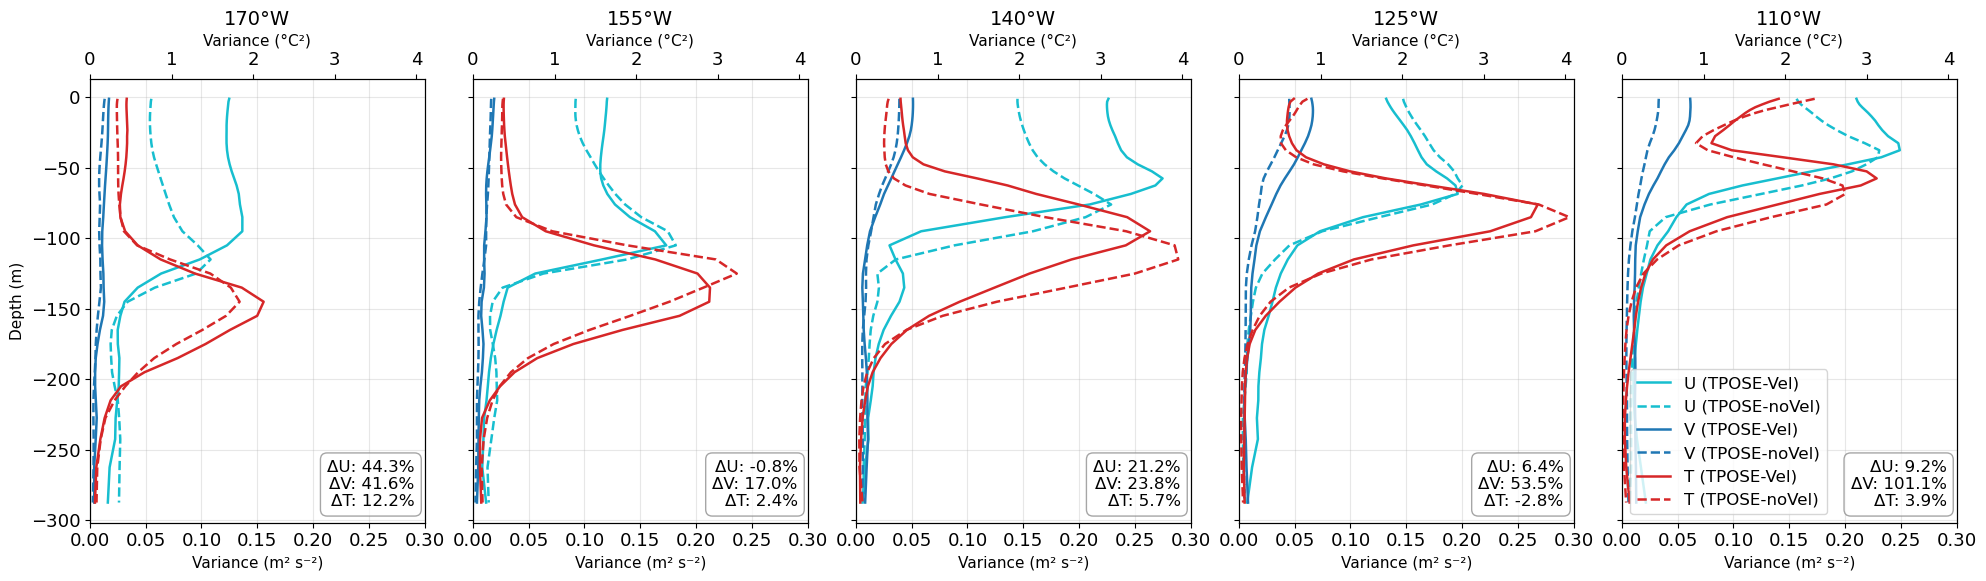

In [18]:
fig, ax = plot_depth_variance(
    variables=[UVEL, UVEL_noTAO, VVEL, VVEL_noTAO],
    labels=['U (TPOSE-Vel)', 'U (TPOSE-noVel)', 'V (TPOSE-Vel)', 'V (TPOSE-noVel)'],
    YC=0,
    lons=[190, 205, 220, 235, 250],
    depth_slice=slice(0, -300),
    colors=['tab:cyan', 'tab:cyan', 'tab:blue', 'tab:blue'],
    linestyles=['-', '--', '-', '--'],
    var_pairs=[(0, 1, 'U'), (2, 3, 'V')],
    variables_ax2=[ds_tpose_TAO.THETA, ds_tpose_noTAO.THETA],
    labels_ax2=['T (TPOSE-Vel)', 'T (TPOSE-noVel)'],
    colors_ax2=['tab:red', 'tab:red'],
    linestyles_ax2=['-', '--'],
    var_pairs_ax2=[(0, 1, 'T')],
    xlabel_ax2='Variance (°C²)',
)
fig.savefig(foldername + 'depth_variance_profiles_theta.png', dpi=300, bbox_inches='tight')

In [47]:
total_var_VVEL = VVEL.sel(YC=0,XC=220,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_UVEL = UVEL.sel(YC=0,XC=220,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_VVEL_noTAO = VVEL_noTAO.sel(YC=0,XC=220,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_UVEL_noTAO = UVEL_noTAO.sel(YC=0,XC=220,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()

# % increase in variance from noTAO to TAO 
percent_increase_VVEL = 100 * (total_var_VVEL - total_var_VVEL_noTAO) / total_var_VVEL_noTAO
percent_increase_UVEL = 100 * (total_var_UVEL - total_var_UVEL_noTAO) / total_var_UVEL_noTAO
print(f"Total variance of VVEL at (YC=0, XC=220) with TAO: {total_var_VVEL.values:.4e} m²/s²")
print(f"Total variance of VVEL at (YC=0, XC=220) without TAO: {total_var_VVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in VVEL variance due to TAO: {percent_increase_VVEL.values:.2f}%")
print(f"Total variance of UVEL at (YC=0, XC=220) with TAO: {total_var_UVEL.values:.4e} m²/s²")
print(f"Total variance of UVEL at (YC=0, XC=220) without TAO: {total_var_UVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in UVEL variance due to TAO: {percent_increase_UVEL.values:.2f}%")

total_var_THETA = ds_tpose_TAO.THETA.sel(YC=0,XC=220,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_THETA_noTAO = ds_tpose_noTAO.THETA.sel(YC=0,XC=220,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()

# % increase in variance from noTAO to TAO 
percent_increase_THETA = 100 * (total_var_THETA - total_var_THETA_noTAO) / total_var_THETA_noTAO
print(f"Total variance of THETA at (YC=0, XC=220) with TAO: {total_var_THETA.values:.4e} m²/s²")
print(f"Total variance of THETA at (YC=0, XC=220) without TAO: {total_var_THETA_noTAO.values:.4e} m²/s²")
print(f"Percent increase in THETA variance due to TAO: {percent_increase_THETA.values:.2f}%")


Total variance of VVEL at (YC=0, XC=220) with TAO: -5.0578e+00 m²/s²
Total variance of VVEL at (YC=0, XC=220) without TAO: -4.0853e+00 m²/s²
Percent increase in VVEL variance due to TAO: 23.80%
Total variance of UVEL at (YC=0, XC=220) with TAO: -2.4778e+01 m²/s²
Total variance of UVEL at (YC=0, XC=220) without TAO: -2.0450e+01 m²/s²
Percent increase in UVEL variance due to TAO: 21.16%
Total variance of THETA at (YC=0, XC=220) with TAO: -3.0039e+02 m²/s²
Total variance of THETA at (YC=0, XC=220) without TAO: -2.8415e+02 m²/s²
Percent increase in THETA variance due to TAO: 5.72%


In [49]:
total_var_VVEL = VVEL.sel(YC=0,XC=250,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_UVEL = UVEL.sel(YC=0,XC=250,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_VVEL_noTAO = VVEL_noTAO.sel(YC=0,XC=250,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_UVEL_noTAO = UVEL_noTAO.sel(YC=0,XC=250,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()

# % increase in variance from noTAO to TAO 
percent_increase_VVEL = 100 * (total_var_VVEL - total_var_VVEL_noTAO) / total_var_VVEL_noTAO
percent_increase_UVEL = 100 * (total_var_UVEL - total_var_UVEL_noTAO) / total_var_UVEL_noTAO
print(f"Total variance of VVEL at (YC=0, XC=250) with TAO: {total_var_VVEL.values:.4e} m²/s²")
print(f"Total variance of VVEL at (YC=0, XC=250) without TAO: {total_var_VVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in VVEL variance due to TAO: {percent_increase_VVEL.values:.2f}%")
print(f"Total variance of UVEL at (YC=0, XC=250) with TAO: {total_var_UVEL.values:.4e} m²/s²")
print(f"Total variance of UVEL at (YC=0, XC=250) without TAO: {total_var_UVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in UVEL variance due to TAO: {percent_increase_UVEL.values:.2f}%")

total_var_THETA = ds_tpose_TAO.THETA.sel(YC=0,XC=250,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_THETA_noTAO = ds_tpose_noTAO.THETA.sel(YC=0,XC=250,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()

# % increase in variance from noTAO to TAO 
percent_increase_THETA = 100 * (total_var_THETA - total_var_THETA_noTAO) / total_var_THETA_noTAO
print(f"Total variance of THETA at (YC=0, XC=250) with TAO: {total_var_THETA.values:.4e} m²/s²")
print(f"Total variance of THETA at (YC=0, XC=250) without TAO: {total_var_THETA_noTAO.values:.4e} m²/s²")
print(f"Percent increase in THETA variance due to TAO: {percent_increase_THETA.values:.2f}%")

Total variance of VVEL at (YC=0, XC=250) with TAO: -5.9615e+00 m²/s²
Total variance of VVEL at (YC=0, XC=250) without TAO: -2.9639e+00 m²/s²
Percent increase in VVEL variance due to TAO: 101.14%
Total variance of UVEL at (YC=0, XC=250) with TAO: -1.8279e+01 m²/s²
Total variance of UVEL at (YC=0, XC=250) without TAO: -1.6740e+01 m²/s²
Percent increase in UVEL variance due to TAO: 9.19%
Total variance of THETA at (YC=0, XC=250) with TAO: -2.0356e+02 m²/s²
Total variance of THETA at (YC=0, XC=250) without TAO: -1.9591e+02 m²/s²
Percent increase in THETA variance due to TAO: 3.91%


In [50]:
total_var_VVEL = VVEL.sel(YC=0,XC=190,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_UVEL = UVEL.sel(YC=0,XC=190,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_VVEL_noTAO = VVEL_noTAO.sel(YC=0,XC=190,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_UVEL_noTAO = UVEL_noTAO.sel(YC=0,XC=190,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()

# % increase in variance from noTAO to TAO 
percent_increase_VVEL = 100 * (total_var_VVEL - total_var_VVEL_noTAO) / total_var_VVEL_noTAO
percent_increase_UVEL = 100 * (total_var_UVEL - total_var_UVEL_noTAO) / total_var_UVEL_noTAO
print(f"Total variance of VVEL at (YC=0, XC=190) with TAO: {total_var_VVEL.values:.4e} m²/s²")
print(f"Total variance of VVEL at (YC=0, XC=190) without TAO: {total_var_VVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in VVEL variance due to TAO: {percent_increase_VVEL.values:.2f}%")
print(f"Total variance of UVEL at (YC=0, XC=190) with TAO: {total_var_UVEL.values:.4e} m²/s²")
print(f"Total variance of UVEL at (YC=0, XC=190) without TAO: {total_var_UVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in UVEL variance due to TAO: {percent_increase_UVEL.values:.2f}%")

total_var_THETA = ds_tpose_TAO.THETA.sel(YC=0,XC=190,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()
total_var_THETA_noTAO = ds_tpose_noTAO.THETA.sel(YC=0,XC=190,method='nearest').sel(Z=slice(0,-300)).var(dim='time').integrate(coord='Z').compute()

# % increase in variance from noTAO to TAO 
percent_increase_THETA = 100 * (total_var_THETA - total_var_THETA_noTAO) / total_var_THETA_noTAO
print(f"Total variance of THETA at (YC=0, XC=190) with TAO: {total_var_THETA.values:.4e} m²/s²")
print(f"Total variance of THETA at (YC=0, XC=190) without TAO: {total_var_THETA_noTAO.values:.4e} m²/s²")
print(f"Percent increase in THETA variance due to TAO: {percent_increase_THETA.values:.2f}%")

Total variance of VVEL at (YC=0, XC=190) with TAO: -2.8049e+00 m²/s²
Total variance of VVEL at (YC=0, XC=190) without TAO: -1.9803e+00 m²/s²
Percent increase in VVEL variance due to TAO: 41.64%
Total variance of UVEL at (YC=0, XC=190) with TAO: -1.9452e+01 m²/s²
Total variance of UVEL at (YC=0, XC=190) without TAO: -1.3478e+01 m²/s²
Percent increase in UVEL variance due to TAO: 44.32%
Total variance of THETA at (YC=0, XC=190) with TAO: -1.9238e+02 m²/s²
Total variance of THETA at (YC=0, XC=190) without TAO: -1.7145e+02 m²/s²
Percent increase in THETA variance due to TAO: 12.21%


In [52]:
total_var_VVEL = VVEL.sel(YC=0,method='nearest').sel(XC=slice(180,260),Z=slice(0,-300)).var(dim='time').integrate(coord='Z').mean(dim='XC').compute()
total_var_UVEL = UVEL.sel(YC=0,method='nearest').sel(XC=slice(180,260),Z=slice(0,-300)).var(dim='time').integrate(coord='Z').mean(dim='XC').compute()
total_var_VVEL_noTAO = VVEL_noTAO.sel(YC=0,method='nearest').sel(XC=slice(180,260),Z=slice(0,-300)).var(dim='time').integrate(coord='Z').mean(dim='XC').compute()
total_var_UVEL_noTAO = UVEL_noTAO.sel(YC=0,method='nearest').sel(XC=slice(180,260),Z=slice(0,-300)).var(dim='time').integrate(coord='Z').mean(dim='XC').compute()

# % increase in variance from noTAO to TAO 
percent_increase_VVEL = 100 * (total_var_VVEL - total_var_VVEL_noTAO) / total_var_VVEL_noTAO
percent_increase_UVEL = 100 * (total_var_UVEL - total_var_UVEL_noTAO) / total_var_UVEL_noTAO
print(f"Total variance of VVEL at (YC=0, XC=(180 to 260)) with TAO: {total_var_VVEL.values:.4e} m²/s²")
print(f"Total variance of VVEL at (YC=0, XC=(180 to 260)) without TAO: {total_var_VVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in VVEL variance due to TAO: {percent_increase_VVEL.values:.2f}%")
print(f"Total variance of UVEL at (YC=0, XC=(180 to 260)) with TAO: {total_var_UVEL.values:.4e} m²/s²")
print(f"Total variance of UVEL at (YC=0, XC=(180 to 260)) without TAO: {total_var_UVEL_noTAO.values:.4e} m²/s²")
print(f"Percent increase in UVEL variance due to TAO: {percent_increase_UVEL.values:.2f}%")

total_var_THETA = ds_tpose_TAO.THETA.sel(YC=0,method='nearest').sel(XC=slice(180,260),Z=slice(0,-300)).var(dim='time').integrate(coord='Z').mean(dim='XC').compute()
total_var_THETA_noTAO = ds_tpose_noTAO.THETA.sel(YC=0,method='nearest').sel(XC=slice(180,260),Z=slice(0,-300)).var(dim='time').integrate(coord='Z').mean(dim='XC').compute()

# % increase in variance from noTAO to TAO 
percent_increase_THETA = 100 * (total_var_THETA - total_var_THETA_noTAO) / total_var_THETA_noTAO
print(f"Total variance of THETA at (YC=0, XC=(180 to 260)) with TAO: {total_var_THETA.values:.4e} m²/s²")
print(f"Total variance of THETA at (YC=0, XC=(180 to 260)) without TAO: {total_var_THETA_noTAO.values:.4e} m²/s²")
print(f"Percent increase in THETA variance due to TAO: {percent_increase_THETA.values:.2f}%")

Total variance of VVEL at (YC=0, XC=(180 to 260)) with TAO: -4.1715e+00 m²/s²
Total variance of VVEL at (YC=0, XC=(180 to 260)) without TAO: -3.2986e+00 m²/s²
Percent increase in VVEL variance due to TAO: 26.46%
Total variance of UVEL at (YC=0, XC=(180 to 260)) with TAO: -1.9812e+01 m²/s²
Total variance of UVEL at (YC=0, XC=(180 to 260)) without TAO: -1.7762e+01 m²/s²
Percent increase in UVEL variance due to TAO: 11.54%
Total variance of THETA at (YC=0, XC=(180 to 260)) with TAO: -2.3412e+02 m²/s²
Total variance of THETA at (YC=0, XC=(180 to 260)) without TAO: -2.2202e+02 m²/s²
Percent increase in THETA variance due to TAO: 5.45%


In [12]:
client.shutdown()
cluster.close()
client.close()